In [ ]:
import pandas as pd
import numpy as np

In [ ]:
np.random.seed(42)
musteri_sayisi=1000

banka_verisi= {
    'Musteri_ID': range(1, musteri_sayisi +1),
    'Yas': np.random.randint(20,65,musteri_sayisi),
    'Yillik_Gelir': np.random.randint(30000,200000,musteri_sayisi),
    'Kredi_Skoru': np.random.randint(300,850,musteri_sayisi),
    'Mevcut_Borc':np.random.randint(0.80000,musteri_sayisi),
    'Gecikme_Gecmisi':np.random.choice([0,1], musteri_sayisi, p=[0.7,0.3])
}

df_banka=pd.DataFrame(banka_verisi)

kural_skor= df_banka['Kredi_Skoru']>600
kural_gelir= df_banka['Yillik_Gelir']> (df_banka['Mevcut_Borc']*2)
kural_gecikme= df_banka['Gecikme_Gecmisi']==0

df_banka['Kredi_Onay']=(kural_skor & kural_gelir & kural_gecikme).astype(int)

print("1000 kişilik veritabanı hazır"),
print(df_banka.head())

1000 kişilik veritabanı hazır
   Musteri_ID  Yas  Yillik_Gelir  Kredi_Skoru  Mevcut_Borc  Gecikme_Gecmisi  \
0           1   58        185002          432          660                1   
1           2   48        161149          603          660                0   
2           3   34        155501          592          660                0   
3           4   62         50611          599          660                0   
4           5   27        178056          342          660                0   

   Kredi_Onay  
0           0  
1           1  
2           0  
3           0  
4           0  


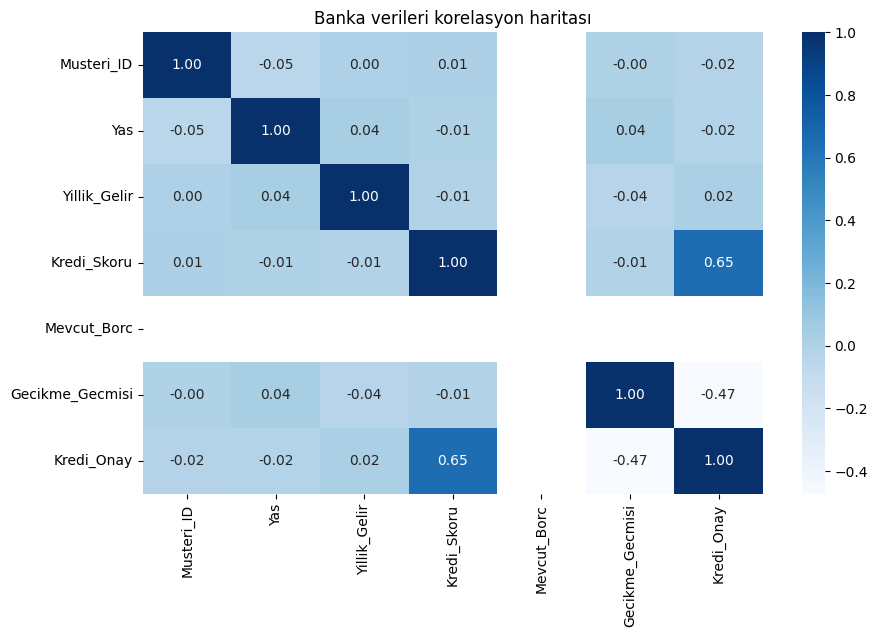

Not: 'Kredi_Onay' satırına bakarak hangi değişkenin onayı daha çok etkilediğini görüyoruz.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(df_banka.corr(),annot=True,cmap='Blues',fmt=".2f")
plt.title('Banka verileri korelasyon haritası')
plt.show()

print("Not: 'Kredi_Onay' satırına bakarak hangi değişkenin onayı daha çok etkilediğini görüyoruz.")



In [ ]:
from sklearn.model_selection import train_test_split

X_sorular = df_banka.drop(['Musteri_ID', 'Kredi_Onay'], axis=1)
y_cevaplar= df_banka['Kredi_Onay']

X_egitim, X_test, y_egitim, y_test = train_test_split(X_sorular, y_cevaplar , test_size=0.2, random_state=42)

print(" Veri eğitim ve test olarak ikiye başarıyla bölündü.")
print(f"Eğitim için kullanılacak müşteri sayısı: {len(X_egitim)}")
print(f"Test için gizlenen müşteri sayısı: {len(X_test)}")

 Veri eğitim ve test olarak ikiye başarıyla bölündü.
Eğitim için kullanılacak müşteri sayısı: 800
Test için gizlenen müşteri sayısı: 200


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

yapay_zeka_modeli= RandomForestClassifier(random_state=42)

yapay_zeka_modeli.fit(X_egitim, y_egitim)

tahminler=yapay_zeka_modeli.predict(X_test)

basari_orani= accuracy_score(y_test, tahminler)

print("Yapay Zeka Eğitildi ve Test Edildi!")
print("-" * 50)
print(f" Modelin Doğruluk Oranı: % {basari_orani * 100}")
print("\n Detaylı Yapay Zeka Karnesi:")
print(classification_report(y_test, tahminler))

Yapay Zeka Eğitildi ve Test Edildi!
--------------------------------------------------
 Modelin Doğruluk Oranı: % 100.0

 Detaylı Yapay Zeka Karnesi:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:


yeni_musteriler = pd.DataFrame({
    'Musteri_Tipi': ['Süper Müşteri', 'Riskli Müşteri'],
    'Yas': [28, 35],
    'Yillik_Gelir': [90000, 45000],
    'Kredi_Skoru': [750, 550],
    'Mevcut_Borc': [20000, 30000],
    'Gecikme_Gecmisi': [0, 1]
})
print(" Yeni Müşteri Başvuruları Alındı:")
print(yeni_musteriler.to_string(index=False))
print("-" * 50)

test_verisi = yeni_musteriler.drop('Musteri_Tipi', axis=1)
kararlar = yapay_zeka_modeli.predict(test_verisi)

for i in range(len(kararlar)):
    isim = yeni_musteriler['Musteri_Tipi'][i]
    if kararlar[i] == 1:
        print(f" {isim} -> KARAR: KREDİ ONAYLANDI! (Güvenilir Profil)")
    else:
        print(f" {isim} -> KARAR: KREDİ REDDEDİLDİ! (Riskli Profil)")

 Yeni Müşteri Başvuruları Alındı:
  Musteri_Tipi  Yas  Yillik_Gelir  Kredi_Skoru  Mevcut_Borc  Gecikme_Gecmisi
 Süper Müşteri   28         90000          750        20000                0
Riskli Müşteri   35         45000          550        30000                1
--------------------------------------------------
 Süper Müşteri -> KARAR: KREDİ ONAYLANDI! (Güvenilir Profil)
 Riskli Müşteri -> KARAR: KREDİ REDDEDİLDİ! (Riskli Profil)
